# Load Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


# Load Cleaned Dataset

In [2]:
df = pd.read_csv("../data/cleaned_online_retail.csv")

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Cleaned dataset loaded successfully!")
print("Shape:", df.shape)

Cleaned dataset loaded successfully!
Shape: (392692, 15)


In [3]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day,Hour,DayOfWeek,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,1,8,Wednesday,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,1,8,Wednesday,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,1,8,Wednesday,2010-12


# 1. Overall Business Metrics

In [4]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()
total_countries = df["Country"].nunique()

print("Total Revenue:", round(total_revenue, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Products:", total_products)
print("Total Countries:", total_countries)

Total Revenue: 8887208.89
Total Orders: 18532
Total Customers: 4338
Total Products: 3665
Total Countries: 37


# 2. Monthly Revenue Trend

In [5]:
monthly_revenue = (
    df.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["YearMonth"] = (
    monthly_revenue["YearMonth"].astype(str)
)

monthly_revenue.head()

,YearMonth,Revenue
0,2010-12,570422.730
1,2011-01,568101.310
2,2011-02,446084.920
3,2011-03,594081.760
4,2011-04,468374.331


# Visualization

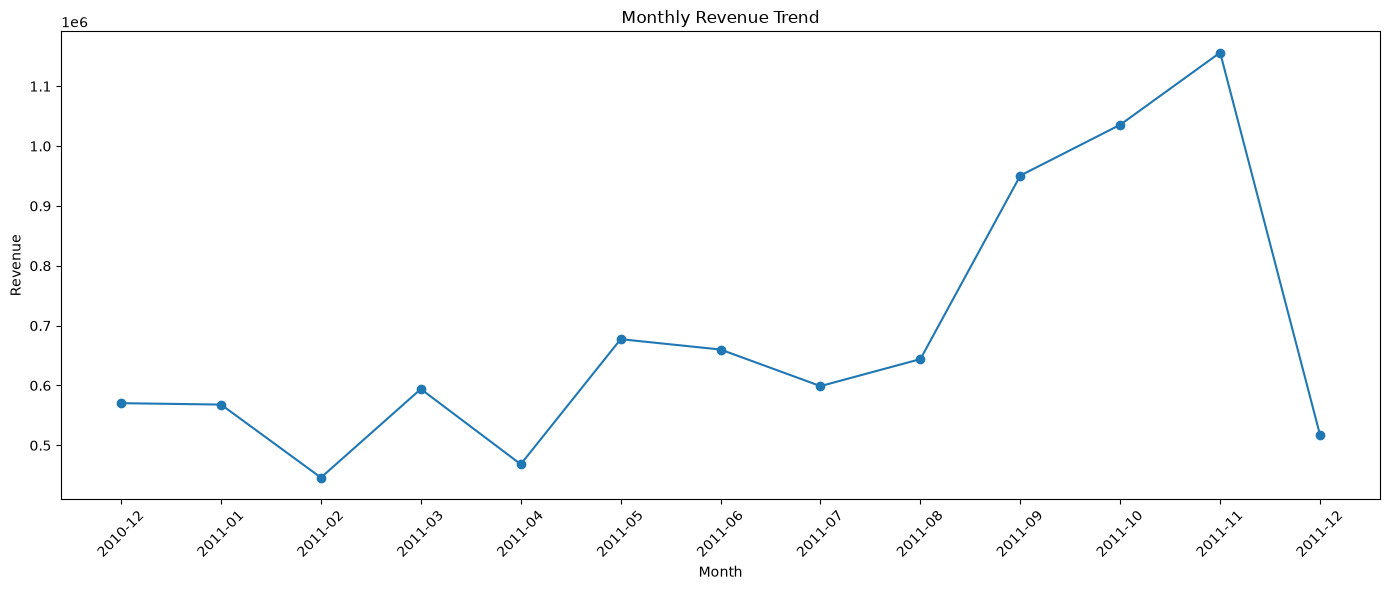

In [6]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue["YearMonth"],
    monthly_revenue["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. Top 10 Products by Revenue

In [7]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

# Chart

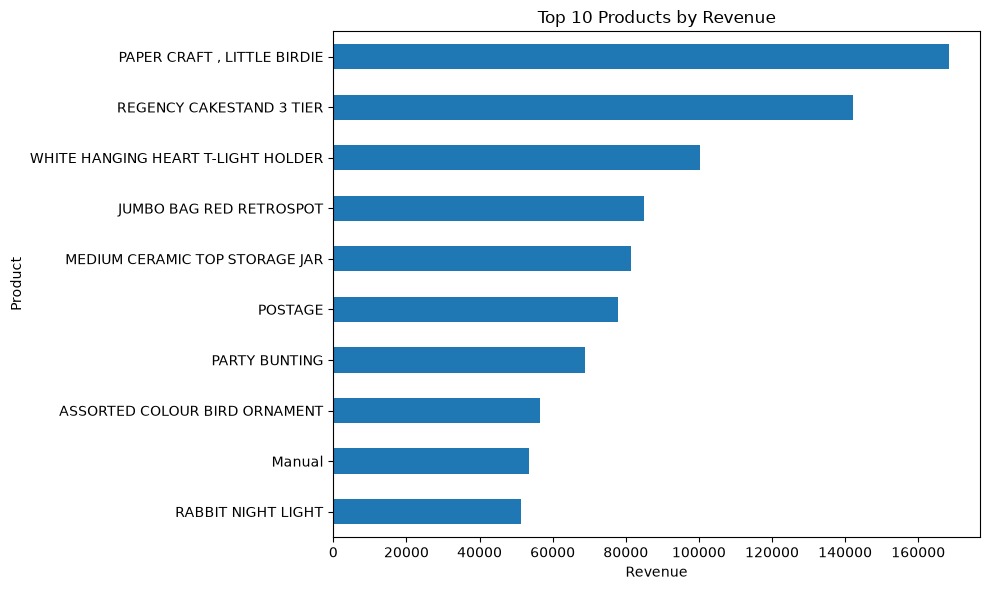

In [8]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

# 4. Top Products by Quantity Sold

In [9]:
top_quantity_products = (
    df.groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_quantity_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

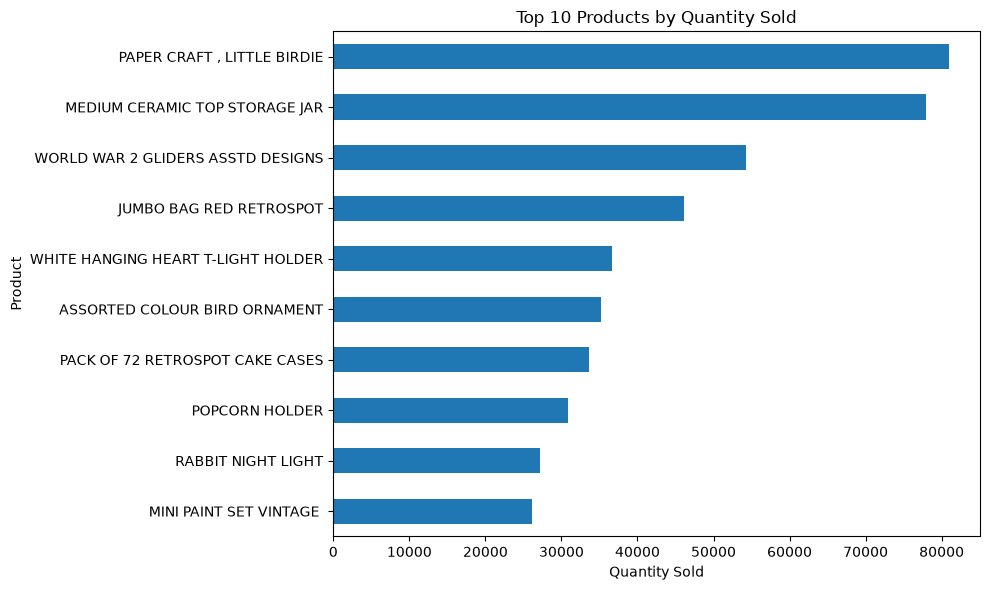

In [10]:
plt.figure(figsize=(10, 6))

top_quantity_products.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

# 5. Country-wise Revenue

In [11]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

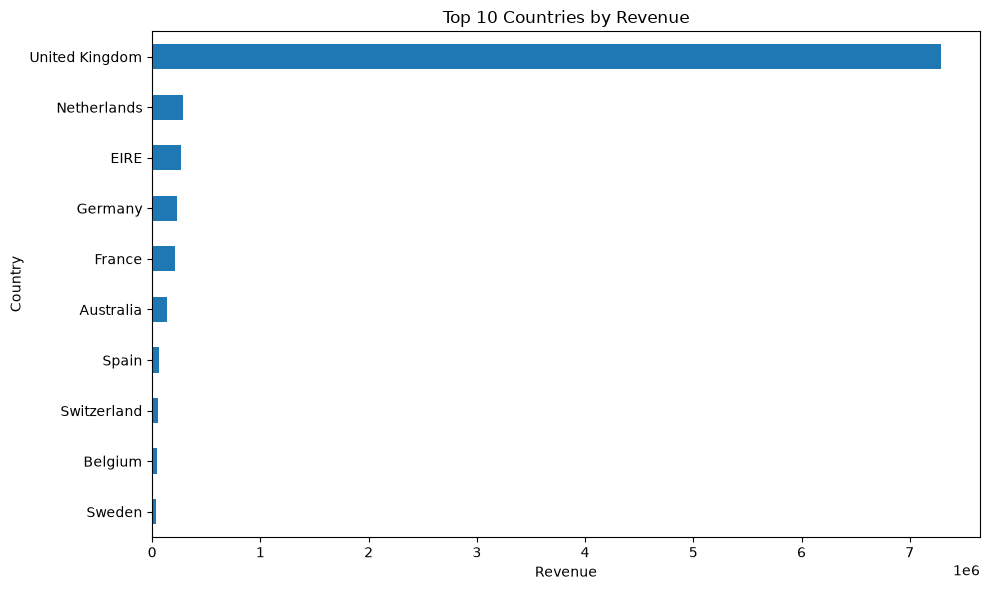

In [12]:
plt.figure(figsize=(10, 6))

country_revenue.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

# 6. Customer Revenue Distribution

In [13]:
customer_revenue = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.describe()

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: Revenue, dtype: float64

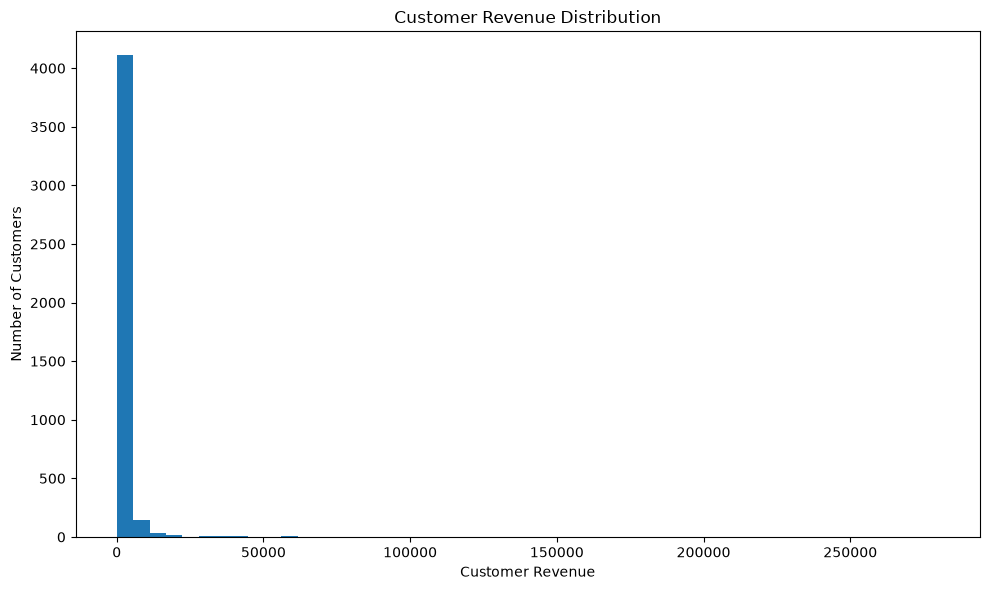

In [14]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_revenue,
    bins=50
)

plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

# 7. Sales by Day of Week

In [15]:
day_sales = (
    df.groupby("DayOfWeek")["Revenue"]
    .sum()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = day_sales.reindex(day_order)

day_sales

DayOfWeek
Monday       1363604.401
Tuesday      1697733.801
Wednesday    1584283.830
Thursday     1973015.730
Friday       1483080.811
Saturday             NaN
Sunday        785490.321
Name: Revenue, dtype: float64

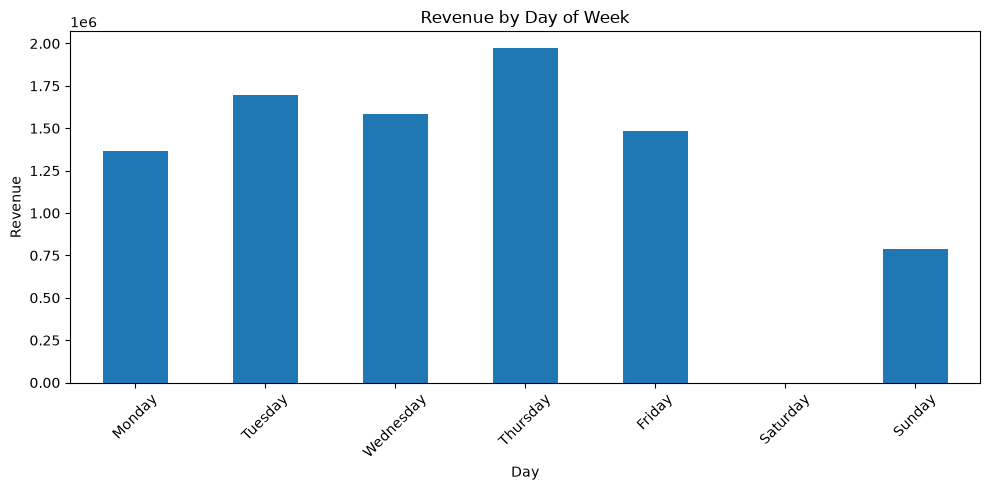

In [16]:
plt.figure(figsize=(10, 5))

day_sales.plot(
    kind="bar"
)

plt.title("Revenue by Day of Week")
plt.xlabel("Day")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 8. Sales by Hour

In [17]:
hourly_sales = (
    df.groupby("Hour")["Revenue"]
    .sum()
)

hourly_sales

Hour
6           4.250
7       31059.210
8      281997.790
9      842392.341
10    1259267.591
11    1101177.600
12    1373695.390
13    1168724.200
14     991992.821
15     963559.680
16     467380.560
17     233811.591
18     104744.990
19      48568.400
20      18832.480
Name: Revenue, dtype: float64

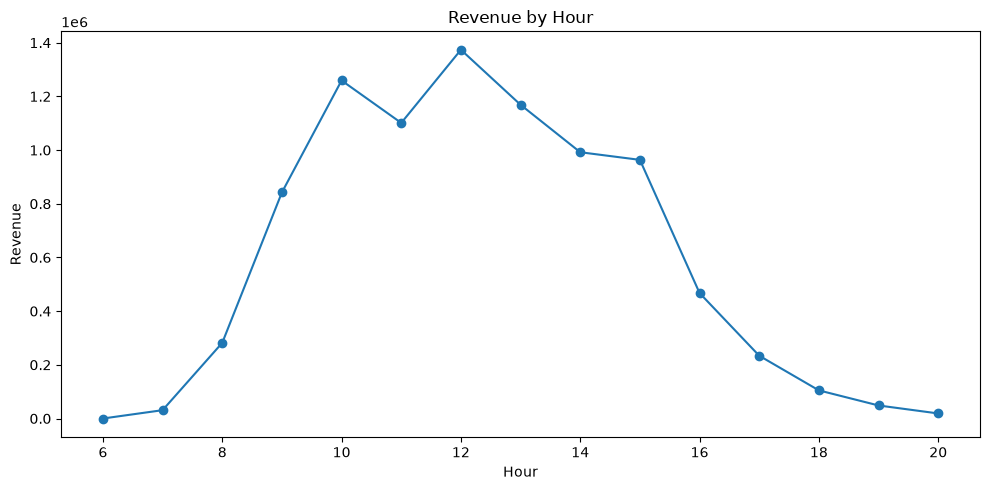

In [18]:
plt.figure(figsize=(10, 5))

hourly_sales.plot(
    kind="line",
    marker="o"
)

plt.title("Revenue by Hour")
plt.xlabel("Hour")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

# 9. Average Order Value

In [19]:
order_revenue = (
    df.groupby("InvoiceNo")["Revenue"]
    .sum()
)

average_order_value = order_revenue.mean()

print(
    "Average Order Value:",
    round(average_order_value, 2)
)

Average Order Value: 479.56


# 10. Orders Per Month

In [20]:
monthly_orders = (
    df.groupby("YearMonth")["InvoiceNo"]
    .nunique()
)

monthly_orders

YearMonth
2010-12    1400
2011-01     987
2011-02     997
2011-03    1321
2011-04    1149
2011-05    1555
2011-06    1393
2011-07    1331
2011-08    1280
2011-09    1755
2011-10    1929
2011-11    2657
2011-12     778
Name: InvoiceNo, dtype: int64

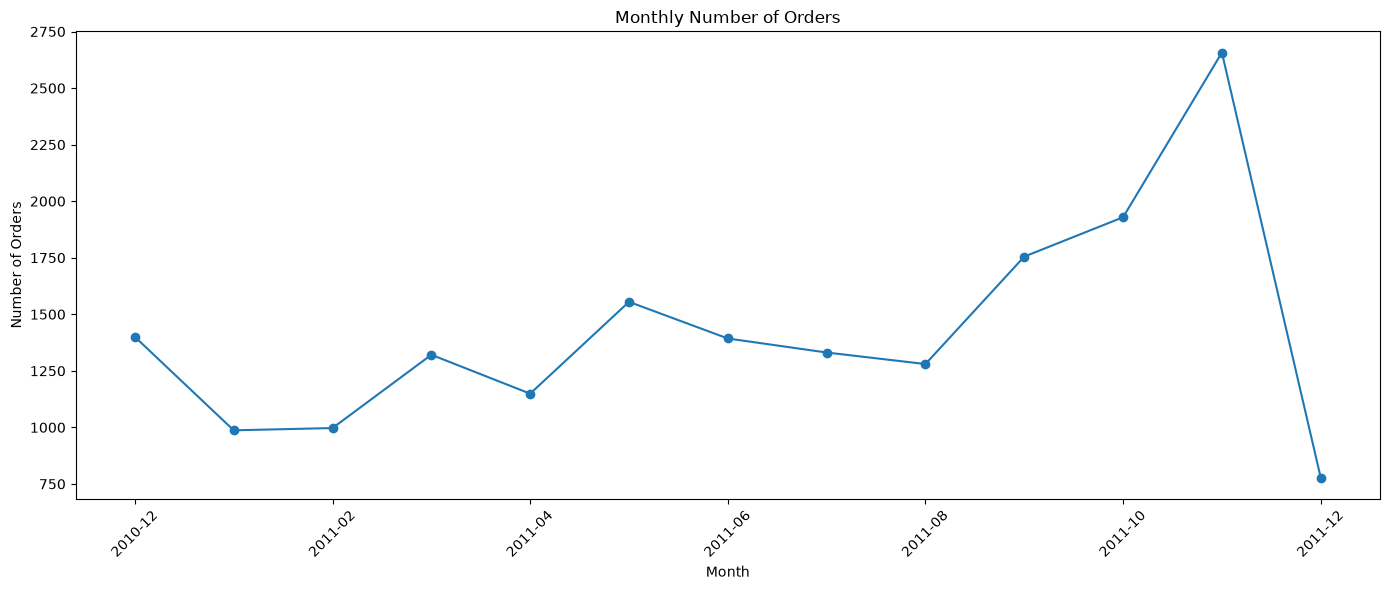

In [21]:
plt.figure(figsize=(14, 6))

monthly_orders.plot(
    kind="line",
    marker="o"
)

plt.title("Monthly Number of Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11. Revenue vs Quantity

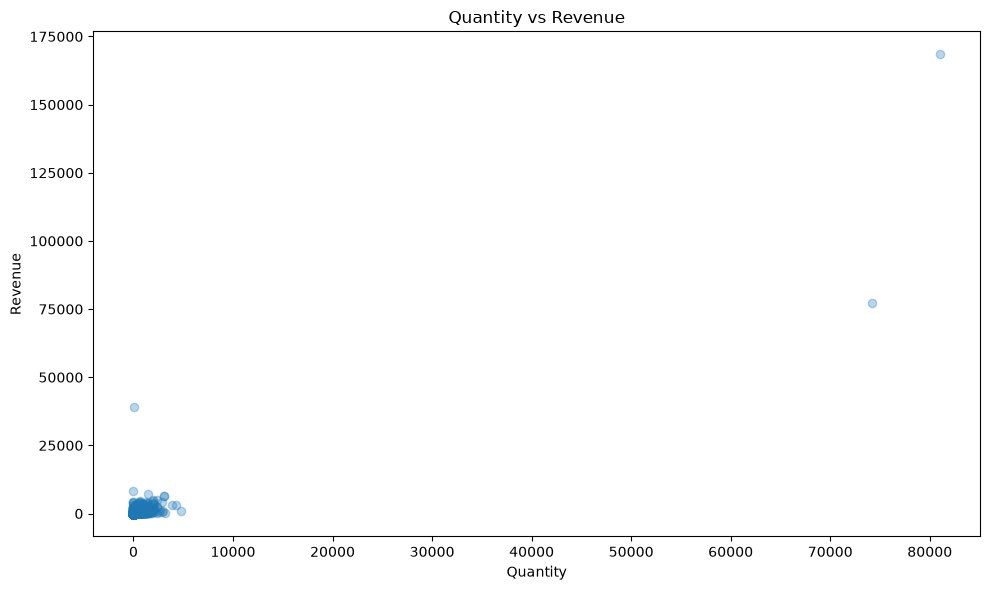

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Quantity"],
    df["Revenue"],
    alpha=0.3
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

# 12. Correlation Analysis

In [23]:
numeric_columns = [
    "Quantity",
    "UnitPrice",
    "Revenue",
    "Year",
    "Month",
    "Day",
    "Hour"
]

correlation = df[numeric_columns].corr()

correlation

,Quantity,UnitPrice,Revenue,Year,Month,Day,Hour
Quantity,1.000000,-0.004578,0.914451,0.001469,-0.004040,-0.001161,-0.014665
UnitPrice,-0.004578,1.000000,0.081619,-0.000203,-0.005063,-0.001297,-0.000217
Revenue,0.914451,0.081619,1.000000,0.000349,-0.002562,-0.001992,-0.013093
Year,0.001469,-0.000203,0.000349,1.000000,-0.340599,0.168157,-0.019772
Month,-0.004040,-0.005063,-0.002562,-0.340599,1.000000,-0.117213,0.058442
Day,-0.001161,-0.001297,-0.001992,0.168157,-0.117213,1.000000,0.008961
Hour,-0.014665,-0.000217,-0.013093,-0.019772,0.058442,0.008961,1.000000


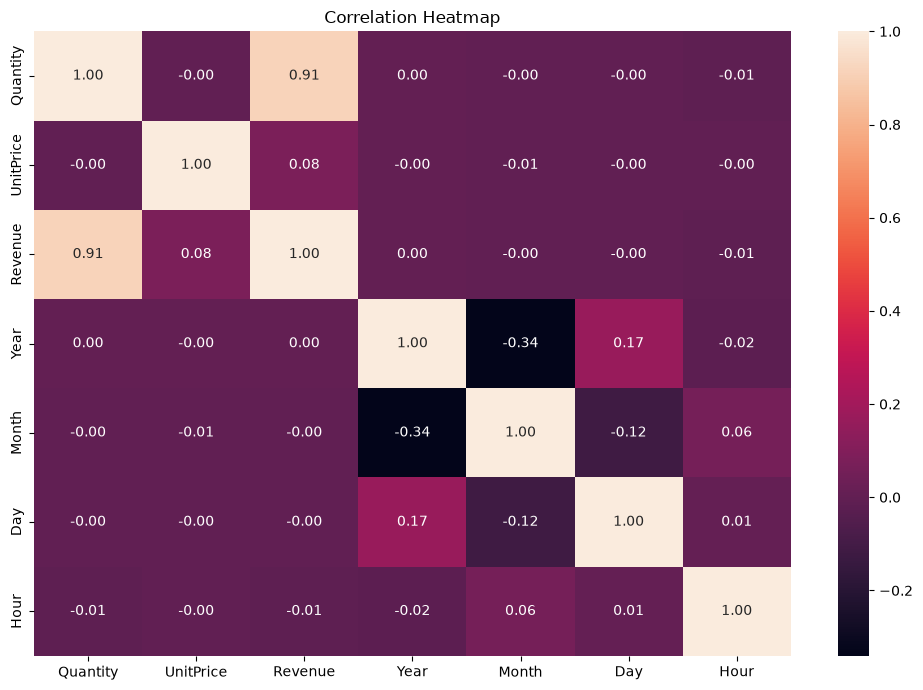

In [24]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

# 13. Top 10 Customers

In [25]:
top_customers = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
12415    124914.53
14156    117210.08
17511     91062.38
16029     80850.84
12346     77183.60
Name: Revenue, dtype: float64

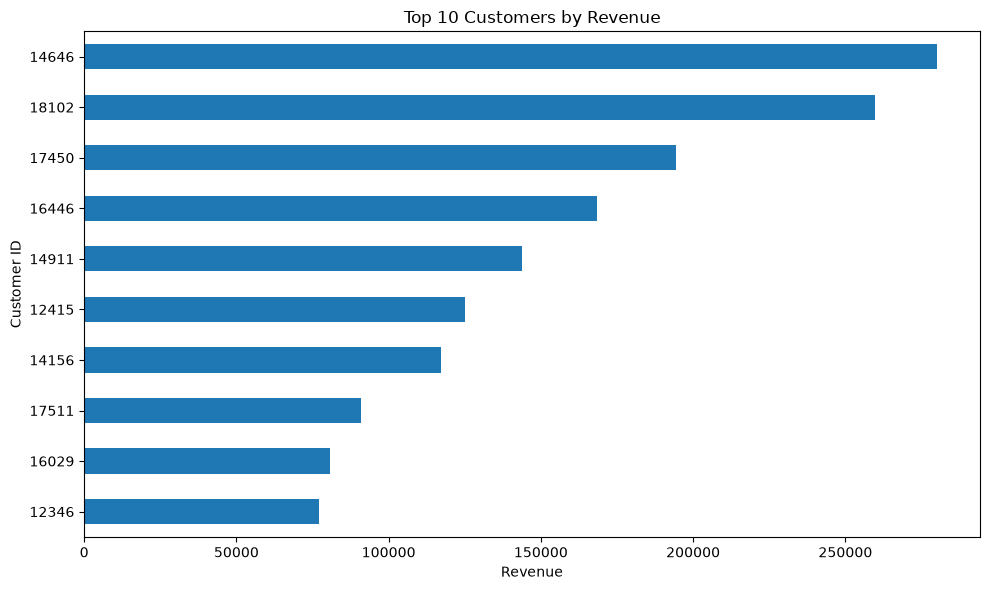

In [26]:
plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.tight_layout()
plt.show()

# 14. Key Business Insights

In [27]:
print("KEY BUSINESS INSIGHTS")
print("=" * 50)

print(
    f"1. Total revenue generated: {total_revenue:,.2f}"
)

print(
    f"2. Total unique customers: {total_customers:,}"
)

print(
    f"3. Total orders: {total_orders:,}"
)

print(
    f"4. Total products: {total_products:,}"
)

print(
    f"5. Top revenue-generating country: "
    f"{country_revenue.index[0]}"
)

print(
    f"6. Top revenue-generating product: "
    f"{top_products.index[0]}"
)

print(
    f"7. Average order value: "
    f"{average_order_value:,.2f}"
)

KEY BUSINESS INSIGHTS
1. Total revenue generated: 8,887,208.89
2. Total unique customers: 4,338
3. Total orders: 18,532
4. Total products: 3,665
5. Top revenue-generating country: United Kingdom
6. Top revenue-generating product: PAPER CRAFT , LITTLE BIRDIE
7. Average order value: 479.56


In [28]:
# Dashboard summary data

import os

os.makedirs("../data/dashboard", exist_ok=True)

# 1. Monthly Revenue
monthly_revenue = (
    df.groupby("YearMonth")["Revenue"]
    .sum()
    .reset_index()
)

monthly_revenue["YearMonth"] = (
    monthly_revenue["YearMonth"].astype(str)
)

monthly_revenue.to_csv(
    "../data/dashboard/monthly_revenue.csv",
    index=False
)


# 2. Top Products
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_products.to_csv(
    "../data/dashboard/top_products.csv",
    index=False
)


# 3. Country Revenue
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

country_revenue.to_csv(
    "../data/dashboard/country_revenue.csv",
    index=False
)


# 4. Day of Week Revenue
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_sales = (
    df.groupby("DayOfWeek")["Revenue"]
    .sum()
    .reindex(day_order)
    .reset_index()
)

day_sales.to_csv(
    "../data/dashboard/day_sales.csv",
    index=False
)


# 5. Overall KPIs
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()

kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Total Products"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        total_products
    ]
})

kpis.to_csv(
    "../data/dashboard/kpis.csv",
    index=False
)

print("Dashboard summary files created successfully!")

Dashboard summary files created successfully!
